# 웹 API 적 위치 → 모의 이동 → 지도 시각화 (모의)

백엔드 **Nest**가 떠 있을 때 `GET /map/infiltrations`, `GET /map/units` 로 적·아군 좌표를 가져온 뒤,
**임의 모의 궤적**(남하 직선 보간 + 작은 노이즈)을 만들고 **Folium**(OpenStreetMap)으로 그립니다.

## 준비

- 터미널에서 백엔드 실행 후 기본 URL `http://localhost:3308` (다르면 환경변수 `API_BASE_URL`).
- `cd vod-devkit` 후 노트북 실행 권장.

```bash
%pip install -q requests folium matplotlib
```

In [25]:
# %pip install -q requests folium matplotlib

In [26]:
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc
FONT_PATH = "C:/Windows/Fonts/malgun.ttf"  # 맑은 고딕
font_name = font_manager.FontProperties(fname=FONT_PATH).get_name()

rc("font", family=font_name)
rc("axes", unicode_minus=False)

# matplotlib 캐시 문제 방지
matplotlib.rcParams["font.family"] = font_name

In [27]:
from __future__ import annotations

import os
from pathlib import Path

import numpy as np
import requests

NOTEBOOK_DIR = Path.cwd().resolve()
API_BASE_URL = os.environ.get("API_BASE_URL", "http://localhost:3308").rstrip("/")

# 프론트 scenarioBattalion.ts 와 동일한 모의 침공 종점 (OSRM/시뮬과 맞춤)
INVASION_TARGET = {"lat": 37.792, "lng": 126.982}

SIM_STEPS = int(os.environ.get("MOCK_SIM_STEPS", "24"))
NOISE_DEG = float(os.environ.get("MOCK_LATLNG_NOISE_DEG", "0.00015"))

print("API_BASE_URL:", API_BASE_URL)
print("SIM_STEPS:", SIM_STEPS, "noise_deg:", NOISE_DEG)

API_BASE_URL: http://localhost:3308
SIM_STEPS: 24 noise_deg: 0.00015


In [28]:
def fetch_json(path: str, timeout: float = 15.0):
    url = f"{API_BASE_URL}{path}"
    r = requests.get(url, timeout=timeout)
    r.raise_for_status()
    return r.json()


try:
    enemies = fetch_json("/map/infiltrations")
    units = fetch_json("/map/units")
    api_ok = True
    print("API OK | 적", len(enemies), "건 | 아군", len(units), "건")
except Exception as e:
    api_ok = False
    enemies = []
    units = []
    print("API 실패 (모의 좌표로 대체):", e)

if not enemies:
    enemies = [
        {
            "id": -1,
            "codename": "모의 적(오프라인)",
            "lat": 38.2,
            "lng": 126.92,
            "threatLevel": "높음",
            "enemyBranch": "데모",
        }
    ]
    print("→ 적 좌표 폴백 사용")

if not units:
    units = [
        {"name": "모의 지휘통제실", "lat": 37.72, "lng": 126.96, "level": "대대"},
    ]

# 우선 표적: 첫 번째 적 (웹 pickPrimaryEnemyForDistance 와 유사하게 id 최소)
primary = sorted(enemies, key=lambda e: e.get("id", 0))[0]
c2 = next((u for u in units if "지휘통제실" in str(u.get("name", ""))), units[0])

print("우선 표적:", primary.get("codename"), "@", primary["lat"], primary["lng"])
print("C2 참조:", c2.get("name"), "@", c2["lat"], c2["lng"])

API OK | 적 1 건 | 아군 7 건
우선 표적: 적 제1기갑대대 (북측 집결) @ 38.2 126.92
C2 참조: 제1기갑대대 지휘통제실 @ 37.72 126.96


In [29]:
def mock_path_southward(
    lat0: float,
    lng0: float,
    lat1: float,
    lng1: float,
    n: int,
    rng: np.random.Generator,
    noise: float,
) -> np.ndarray:
    """0..1 직선 보간 + 작은 임의 흔들림 (위도·경도 단위)."""
    t = np.linspace(0.0, 1.0, n)
    lat = lat0 + (lat1 - lat0) * t + rng.normal(0, noise, size=n)
    lng = lng0 + (lng1 - lng0) * t + rng.normal(0, noise, size=n)
    return np.column_stack([lat, lng])


rng = np.random.default_rng(int(os.environ.get("MOCK_SEED", "42")))
path = mock_path_southward(
    float(primary["lat"]),
    float(primary["lng"]),
    INVASION_TARGET["lat"],
    INVASION_TARGET["lng"],
    SIM_STEPS,
    rng,
    NOISE_DEG,
)

print("모의 궤적 점 수:", path.shape[0])
print("시작:", path[0].round(5))
print("종료:", path[-1].round(5))

모의 궤적 점 수: 24
시작: [ 38.20005 126.91994]
종료: [ 37.79198 126.98203]


In [30]:
import folium
from folium import plugins

mid_lat = float(np.mean([path[:, 0].mean(), float(c2["lat"])]))
mid_lng = float(np.mean([path[:, 1].mean(), float(c2["lng"])]))

m = folium.Map(location=[mid_lat, mid_lng], zoom_start=9, tiles="OpenStreetMap")

folium.Marker(
    [float(c2["lat"]), float(c2["lng"])],
    tooltip=c2.get("name", "C2"),
    icon=folium.Icon(color="blue", icon="info-sign"),
).add_to(m)

folium.Marker(
    [float(primary["lat"]), float(primary["lng"])],
    tooltip=f"API 적 초기: {primary.get('codename', '')}",
    icon=folium.Icon(color="green", icon="play"),
).add_to(m)

folium.PolyLine(
    locations=path[:, [0, 1]].tolist(),
    color="#dc2626",
    weight=4,
    opacity=0.85,
    tooltip="모의 남하 궤적",
).add_to(m)

folium.CircleMarker(
    location=[path[-1, 0], path[-1, 1]],
    radius=8,
    color="darkred",
    fill=True,
    tooltip="모의 종료 시점",
).add_to(m)

folium.Marker(
    [INVASION_TARGET["lat"], INVASION_TARGET["lng"]],
    tooltip="시나리오 invasionTarget (참고)",
    icon=folium.Icon(color="gray", icon="flag"),
).add_to(m)

plugins.AntPath(path[:, [0, 1]].tolist(), color="#f59e0b", weight=3, delay=800).add_to(m)

_lats = np.r_[path[:, 0], [float(c2["lat"]), float(primary["lat"]), INVASION_TARGET["lat"]]]
_lngs = np.r_[path[:, 1], [float(c2["lng"]), float(primary["lng"]), INVASION_TARGET["lng"]]]
pad_lat = max(0.02, (_lats.max() - _lats.min()) * 0.08)
pad_lng = max(0.02, (_lngs.max() - _lngs.min()) * 0.08)
m.fit_bounds(
    [[_lats.min() - pad_lat, _lngs.min() - pad_lng], [_lats.max() + pad_lat, _lngs.max() + pad_lng]]
)

out_html = NOTEBOOK_DIR / "_nb_web_enemy_mock_map.html"
m.save(str(out_html))
print("HTML 저장:", out_html)
m

HTML 저장: C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\_nb_web_enemy_mock_map.html


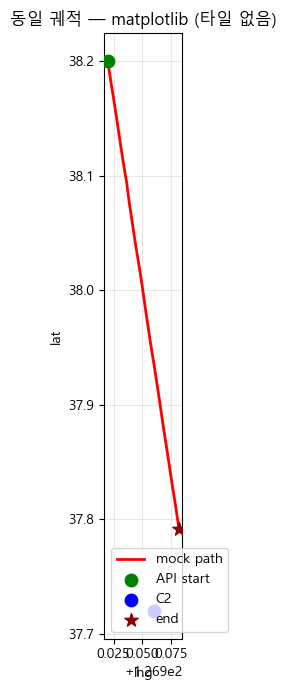

In [31]:
# Jupyter 없이 저장본만 볼 때: 브라우저로 _nb_web_enemy_mock_map.html 열기
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(path[:, 1], path[:, 0], "r-", linewidth=2, label="mock path")
ax.scatter([float(primary["lng"])], [float(primary["lat"])], c="green", s=80, zorder=5, label="API start")
ax.scatter([float(c2["lng"])], [float(c2["lat"])], c="blue", s=80, zorder=5, label="C2")
ax.scatter(path[-1, 1], path[-1, 0], c="darkred", s=100, marker="*", zorder=5, label="end")
ax.set_xlabel("lng")
ax.set_ylabel("lat")
ax.set_title("동일 궤적 — matplotlib (타일 없음)")
ax.set_aspect("equal")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 메모

- **실제 웹(카카오맵)** 과 타일·투영은 다르지만, **같은 API 좌표(WGS84)** 를 씁니다.
- OSRM 도로를 쓰려면 같은 백엔드 `GET /map/route/driving` 으로 좌표열을 받아 `folium.PolyLine` 에 넣으면 됩니다.
- `API_BASE_URL`, `MOCK_SIM_STEPS`, `MOCK_SEED`, `MOCK_LATLNG_NOISE_DEG` 로 조정 가능합니다.